In [6]:
"""
Project 02 – Return Structure
Step: Distributional diagnostics

Objective:
Examine the empirical distributional properties of daily log returns.
Compare signed returns and absolute returns to identify structural
differences without making any predictive or modeling claims.

Scope:
- Descriptive analysis only
- No prediction
- No machine learning
- No model fitting

Outputs:
- artifacts/returns_ts.png
- artifacts/signed_hist.png
- artifacts/abs_hist.png
- artifacts/stats.json
"""

'\nProject 02 – Return Structure\nStep: Distributional diagnostics\n\nObjective:\nExamine the empirical distributional properties of daily log returns.\nCompare signed returns and absolute returns to identify structural\ndifferences without making any predictive or modeling claims.\n\nScope:\n- Descriptive analysis only\n- No prediction\n- No machine learning\n- No model fitting\n\nOutputs:\n- artifacts/returns_ts.png\n- artifacts/signed_hist.png\n- artifacts/abs_hist.png\n- artifacts/stats.json\n'

In [7]:
import sys
from pathlib import Path

project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf


In [9]:
from return_predictability.src.load_data import load_data 
from return_predictability.src.returns import compute_log_returns

In [10]:
df=load_data("tsla.csv")
price=df["price"]
price.head()

Date
2010-06-29    1.59267
2010-06-30    1.58867
2010-07-01    1.46400
2010-07-02    1.28000
2010-07-06    1.07400
Name: price, dtype: float64

In [11]:
returns=compute_log_returns(price)
returns.head()

Date
2010-06-29         NaN
2010-06-30   -0.002515
2010-07-01   -0.081725
2010-07-02   -0.134312
2010-07-06   -0.175470
Name: price, dtype: float64

In [12]:
signed_returns = returns.dropna()
abs_returns = returns.abs().dropna() # |returns|
abs_returns.head()

Date
2010-06-30    0.002515
2010-07-01    0.081725
2010-07-02    0.134312
2010-07-06    0.175470
2010-07-07    0.019433
Name: price, dtype: float64

Text(0.5, 0, 'Date')

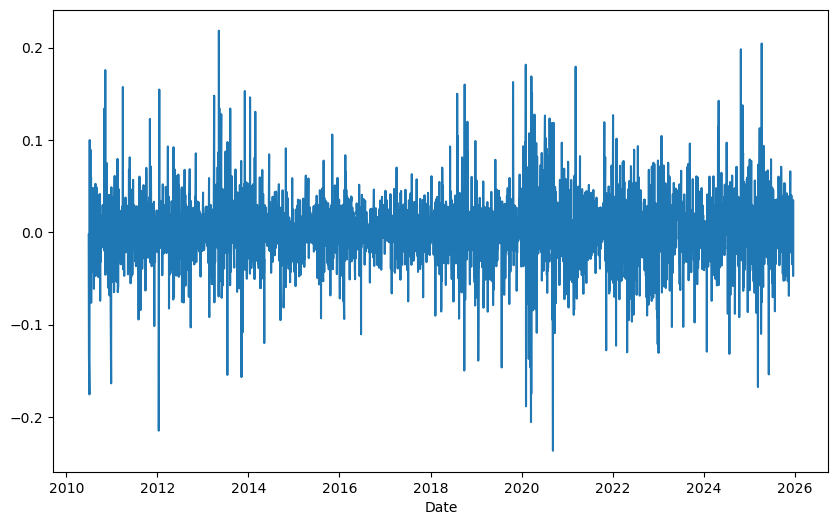

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(signed_returns.index, signed_returns)
plt.xlabel('Date')

In [14]:
### Time Series of Signed Log Returns
"""
This plot shows the signed daily log returns over time,
 capturing both the direction and magnitude of price changes.

The series fluctuates around zero with frequent sign changes
 and no visually persistent directional trends.
  Positive and negative returns appear interspersed in an irregular manner.

Unlike absolute returns, signed returns do not display
 clear clustering or long-lasting regimes.
   This suggests that **return direction behaves largely like noise**,
     with little temporal dependence.

While extreme positive and negative returns do occur,
 they do not form sustained directional patterns,
   reinforcing the view that daily return direction is difficult to predict.
"""

'\nThis plot shows the signed daily log returns over time,\n capturing both the direction and magnitude of price changes.\n\nThe series fluctuates around zero with frequent sign changes\n and no visually persistent directional trends.\n  Positive and negative returns appear interspersed in an irregular manner.\n\nUnlike absolute returns, signed returns do not display\n clear clustering or long-lasting regimes.\n   This suggests that **return direction behaves largely like noise**,\n     with little temporal dependence.\n\nWhile extreme positive and negative returns do occur,\n they do not form sustained directional patterns,\n   reinforcing the view that daily return direction is difficult to predict.\n'

Text(0.5, 0, 'Date')

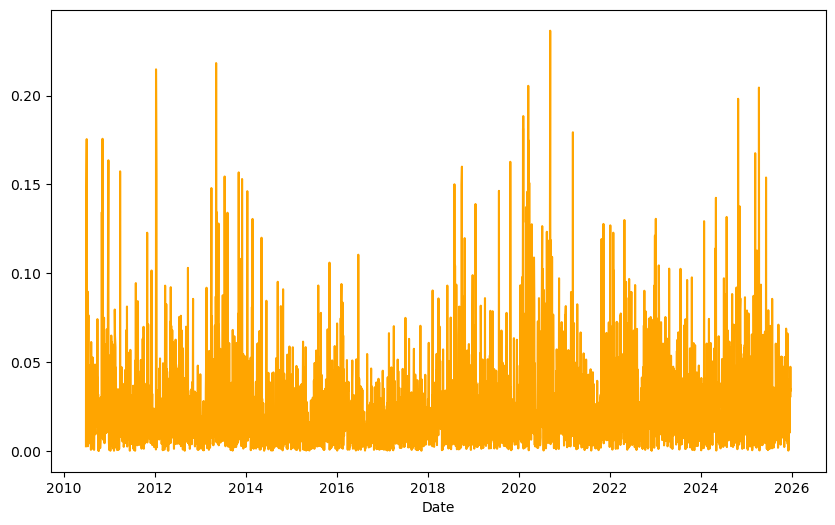

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(abs_returns.index, abs_returns,color='orange')
plt.xlabel('Date')

In [16]:
### Time Series of Absolute Log Returns
"""
This plot shows the absolute daily log returns over time,
 representing the magnitude of price movements regardless of direction.

The series exhibits clear periods of elevated and subdued activity.
 High-volatility episodes tend to cluster together,
   followed by relatively calm periods, rather than appearing randomly over time.

This visual pattern is a classic example of **volatility clustering**:
    large price movements are likely to be followed by other large movements,
    and small movements tend to persist as well.

Importantly, this structure reflects persistence in *risk*
 rather than predictability of returns. 

The timing of high-volatility periods is not random, even though their direction is.
"""

'\nThis plot shows the absolute daily log returns over time,\n representing the magnitude of price movements regardless of direction.\n\nThe series exhibits clear periods of elevated and subdued activity.\n High-volatility episodes tend to cluster together,\n   followed by relatively calm periods, rather than appearing randomly over time.\n\nThis visual pattern is a classic example of **volatility clustering**:\n    large price movements are likely to be followed by other large movements,\n    and small movements tend to persist as well.\n\nImportantly, this structure reflects persistence in *risk*\n rather than predictability of returns. \n\nThe timing of high-volatility periods is not random, even though their direction is.\n'

Text(0.5, 0, 'Log Returns')

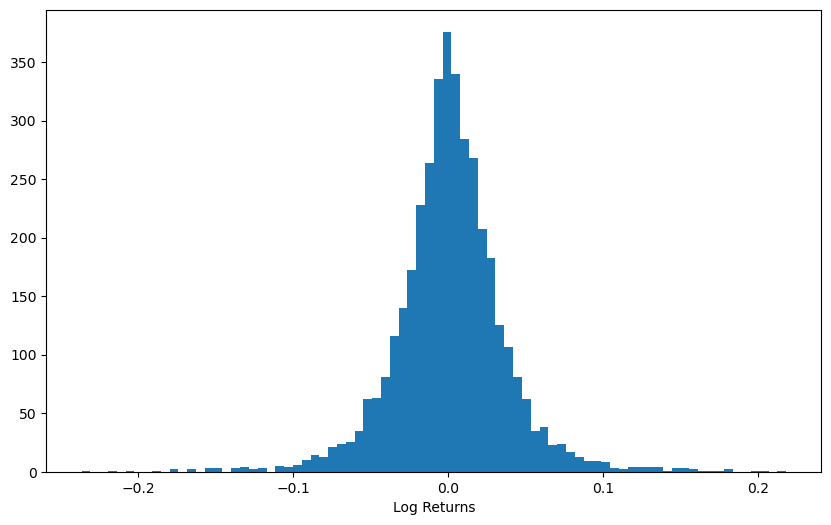

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(signed_returns, bins=80)
plt.xlabel('Log Returns')

In [18]:
### Histogram of Signed Log Returns
"""
This histogram shows the distribution of signed daily log returns,
capturing both the direction and magnitude of price changes.

The distribution is centered close to zero and appears approximately symmetric,
with positive and negative returns occurring with similar frequency.

However, the tails are heavier than those of a normal distribution,
indicating a higher probability of extreme outcomes
than would be expected under Gaussian assumptions.

This pattern suggests that while daily return directions do not exhibit systematic bias,
**extreme movements occur more frequently than predicted by simple normal models**.

Overall, the histogram reinforces the view that return directions are largely unpredictable,
but their distribution deviates significantly from classical normality.
"""

'\nThis histogram shows the distribution of signed daily log returns,\ncapturing both the direction and magnitude of price changes.\n\nThe distribution is centered close to zero and appears approximately symmetric,\nwith positive and negative returns occurring with similar frequency.\n\nHowever, the tails are heavier than those of a normal distribution,\nindicating a higher probability of extreme outcomes\nthan would be expected under Gaussian assumptions.\n\nThis pattern suggests that while daily return directions do not exhibit systematic bias,\n**extreme movements occur more frequently than predicted by simple normal models**.\n\nOverall, the histogram reinforces the view that return directions are largely unpredictable,\nbut their distribution deviates significantly from classical normality.\n'

Text(0.5, 0, 'Absolute Log Returns')

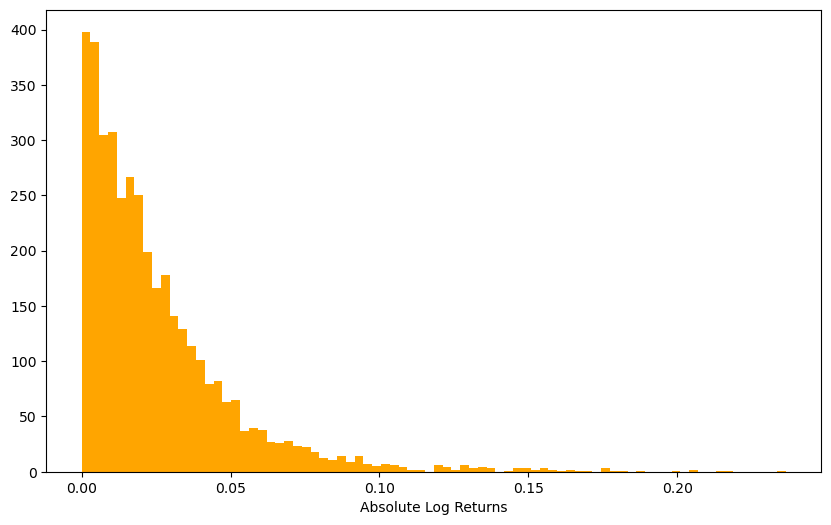

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(abs_returns, bins=80, color='orange')
plt.xlabel('Absolute Log Returns')


In [20]:
### Histogram of Absolute Log Returns
"""
This histogram shows the distribution of absolute daily log returns, 
which capture the *magnitude* of price movements regardless of direction.

The distribution is strongly right-skewed:
    most observations are concentrated near zero,
    indicating that the majority of trading days experience small price changes. 
However, there is a long right tail, reflecting the presence of rare but very large movements.

This shape highlights the **non-Gaussian and fat-tailed nature of financial returns**. 
Risk is not evenly distributed over time:
    extreme volatility events are infrequent but significant.

Importantly, this distribution describes the 'nature of risk', not return predictability. 
It provides evidence of heterogeneous volatility rather than directional forecasting power.
"""

"\nThis histogram shows the distribution of absolute daily log returns, \nwhich capture the *magnitude* of price movements regardless of direction.\n\nThe distribution is strongly right-skewed:\n    most observations are concentrated near zero,\n    indicating that the majority of trading days experience small price changes. \nHowever, there is a long right tail, reflecting the presence of rare but very large movements.\n\nThis shape highlights the **non-Gaussian and fat-tailed nature of financial returns**. \nRisk is not evenly distributed over time:\n    extreme volatility events are infrequent but significant.\n\nImportantly, this distribution describes the 'nature of risk', not return predictability. \nIt provides evidence of heterogeneous volatility rather than directional forecasting power.\n"

Text(0, 0.5, 'ACF of returns')

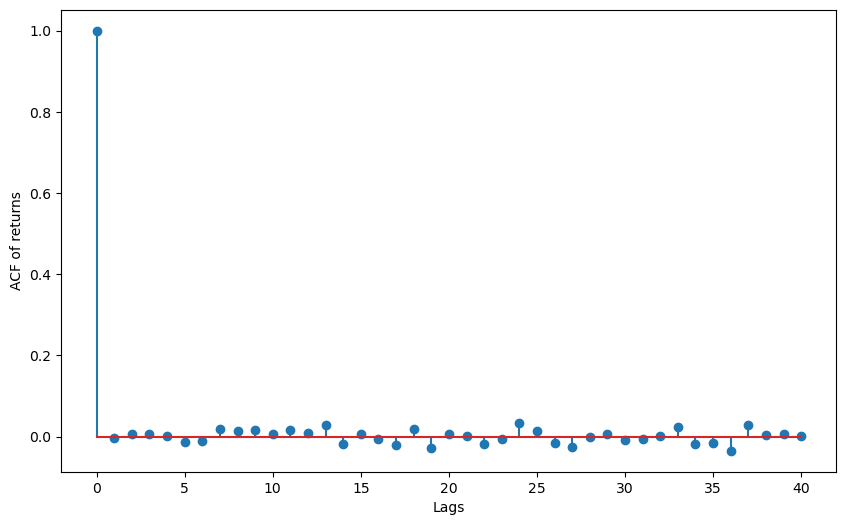

In [21]:
acf_returns = acf(signed_returns, nlags=40)
plt.figure(figsize=(10, 6))
plt.stem(acf_returns)
plt.xlabel('Lags')
plt.ylabel('ACF of returns')


In [22]:
### ACF of Signed Returns
"""
This plot shows the autocorrelation function (ACF) of signed daily log returns.

The autocorrelations beyond lag 0 are very close to zero and fluctuate randomly around zero. 
There is no clear persistence or systematic pattern across lags,
and the correlations decay immediately.

This indicates that daily return directions are largely memoryless. 
Past returns do not provide meaningful information about future return direction,
which is consistent with the weak-form efficiency of financial markets.

In other words, while prices may move up or down each day,
the direction of those moves does not exhibit stable temporal dependence.
"""

'\nThis plot shows the autocorrelation function (ACF) of signed daily log returns.\n\nThe autocorrelations beyond lag 0 are very close to zero and fluctuate randomly around zero. \nThere is no clear persistence or systematic pattern across lags,\nand the correlations decay immediately.\n\nThis indicates that daily return directions are largely memoryless. \nPast returns do not provide meaningful information about future return direction,\nwhich is consistent with the weak-form efficiency of financial markets.\n\nIn other words, while prices may move up or down each day,\nthe direction of those moves does not exhibit stable temporal dependence.\n'

Text(0, 0.5, 'ACF of |returns|')

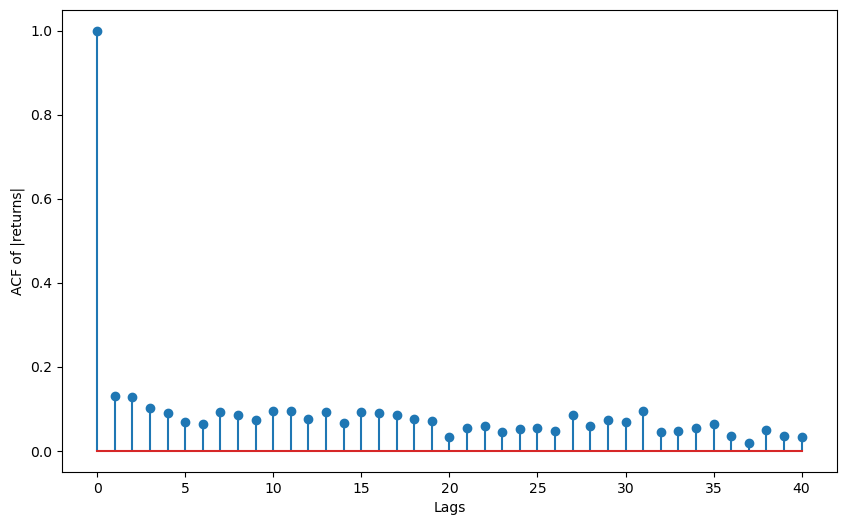

In [23]:
acf_abs_returns = acf(abs_returns, nlags=40)
plt.figure(figsize=(10, 6))
plt.stem(acf_abs_returns)
plt.xlabel('Lags')
plt.ylabel('ACF of |returns|')


In [24]:
### ACF of Absolute Returns
"""
This plot shows the autocorrelation function (ACF) of absolute daily log returns,
which proxy return magnitude and volatility.

Unlike signed returns, absolute returns exhibit
positive and slowly decaying autocorrelation across multiple lags.

The first few lags are clearly positive,
and the correlations decrease gradually rather than disappearing immediately.

This behavior indicates **volatility clustering**:
    periods of high volatility tend to be followed by high volatility,
    and calm periods tend to persist as well.

Importantly, this structure reflects persistence in 'risk',
not predictability of return direction. 
The market may be unpredictable in terms of direction,
but it is not memoryless in terms of volatility.
"""

"\nThis plot shows the autocorrelation function (ACF) of absolute daily log returns,\nwhich proxy return magnitude and volatility.\n\nUnlike signed returns, absolute returns exhibit\npositive and slowly decaying autocorrelation across multiple lags.\n\nThe first few lags are clearly positive,\nand the correlations decrease gradually rather than disappearing immediately.\n\nThis behavior indicates **volatility clustering**:\n    periods of high volatility tend to be followed by high volatility,\n    and calm periods tend to persist as well.\n\nImportantly, this structure reflects persistence in 'risk',\nnot predictability of return direction. \nThe market may be unpredictable in terms of direction,\nbut it is not memoryless in terms of volatility.\n"

In [26]:
from scipy.stats import skew, kurtosis

stats = {
    "signed_returns": {
        "mean": float(signed_returns.mean()),
        "std": float(signed_returns.std()),
        "skew": float(skew(signed_returns)),
        "kurtosis": float(kurtosis(signed_returns))  # Fisher kurtosis (normal = 0)
    },
    "absolute_returns": {
        "mean": float(abs_returns.mean()),
        "std": float(abs_returns.std()),
        "skew": float(skew(abs_returns)),
        "kurtosis": float(kurtosis(abs_returns))
    }
}

stats


{'signed_returns': {'mean': 0.001468505208544643,
  'std': 0.0362798810081474,
  'skew': 0.006020324482395231,
  'kurtosis': 4.697733106924284},
 'absolute_returns': {'mean': 0.02531840713776892,
  'std': 0.026023073281605552,
  'skew': 2.5140418123673163,
  'kurtosis': 9.758170613101665}}

In [ ]:
#